## **FIFA PLAYER STATISTICS ANALYSIS**

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("fifa_csv.csv")

In [3]:
print(df.columns.tolist())

['Unnamed: 0', 'sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club_name', 'league_name', 'league_rank', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions'

In [4]:
df.rename(columns = {
    'age': 'Age',
    'overall': 'Overall',
    'potential': 'Potential',
    'value_eur': 'Value in Euro',
    'wage_eur': 'Wage in Euro',
    'club_name': 'Club Name',
    'nationality': 'Nationality',
    'player_positions': 'Position',
    'short_name': 'Short Name'
},
inplace = True)

In [5]:
print(df.columns.tolist())

['Unnamed: 0', 'sofifa_id', 'player_url', 'Short Name', 'long_name', 'Age', 'dob', 'height_cm', 'weight_kg', 'Nationality', 'Club Name', 'league_name', 'league_rank', 'Overall', 'Potential', 'Value in Euro', 'Wage in Euro', 'Position', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions'

## BEST RATED PLAYERS

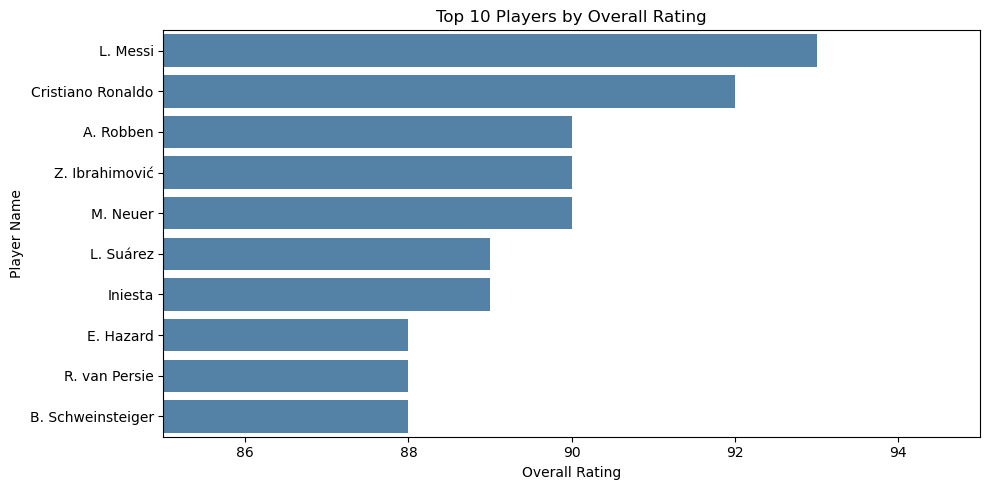

In [18]:
plt.figure(figsize = (10 , 5))

sns.barplot(
    data = top,
    x = 'Overall',
    y ='Short Name',
    color = 'steelblue'
)

plt.xlim(85 , 95)
plt.title("Top 10 Players by Overall Rating")
plt.xlabel("Overall Rating")
plt.ylabel("Player Name")

plt.tight_layout()
plt.show()

## Age and Overall Rating Distribution

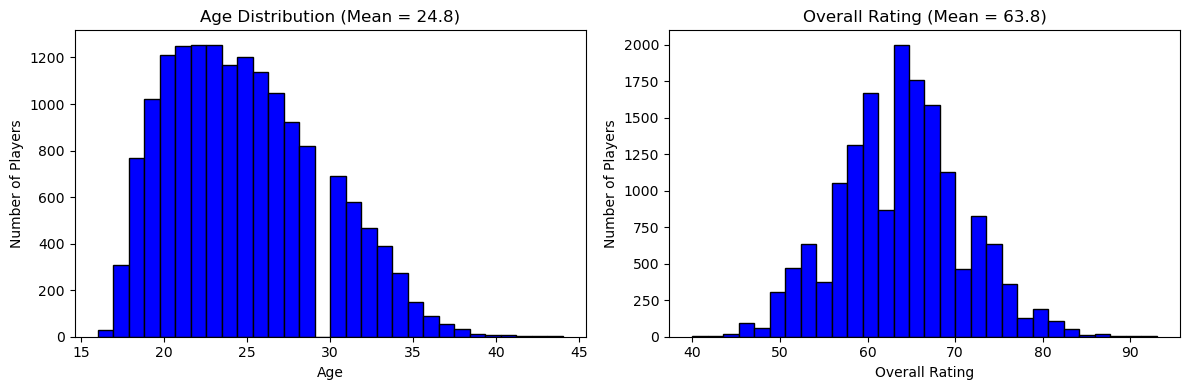

In [22]:
fig, ax = plt.subplots(1, 2 , figsize = (12 , 4))

ax[0].hist(df['Age'] , bins = 30 , color = 'blue' , edgecolor = 'black')
ax[0].set_title(f"Age Distribution (Mean = {df['Age'].mean():.1f})")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Number of Players")

ax[1].hist(df['Overall'] , bins = 30 , color = 'blue' , edgecolor = 'black')
ax[1].set_title(f"Overall Rating (Mean = {df['Overall'].mean():.1f})")
ax[1].set_xlabel("Overall Rating")
ax[1].set_ylabel("Number of Players")

plt.tight_layout()
plt.show()


## PLAYERS' NATIONALITY

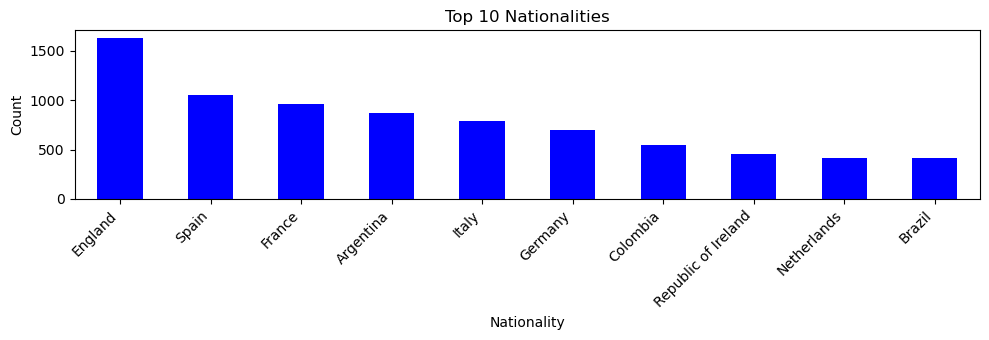

In [26]:
nat = df['Nationality'].value_counts().head(10)
fig, ax = plt.subplots(figsize = (10,3.5))

nat.plot(kind = 'bar' , 
         ax = ax,
        color = 'blue'
)
plt.xticks(rotation = 45 , ha = 'right')

plt.title("Top 10 Nationalities")
plt.xlabel("Nationality")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## MARKET VALUE of PLAYERS

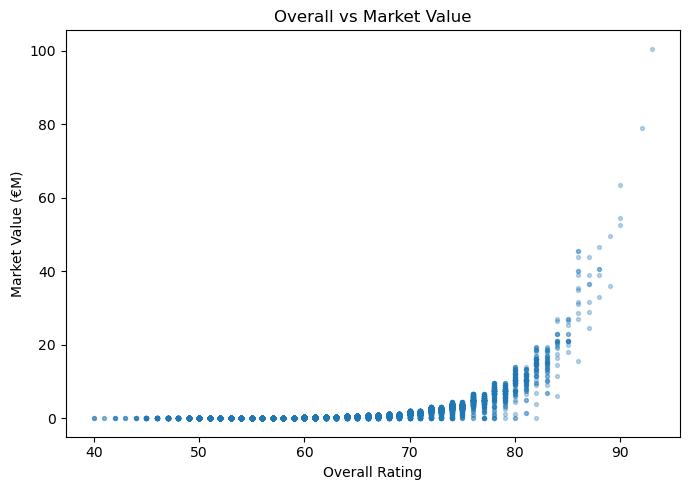

Correlation(value, overall): 0.569
Correlation(log value, overall): 0.562


In [32]:
d = df.dropna(subset = ['Value in Euro' , 'Overall'])
fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(
    d['Overall'],
    d['Value in Euro'] / 1e6,
    alpha = 0.3, 
    s = 8
)
ax.set_xlabel('Overall Rating')
ax.set_ylabel('Market Value (€M)')
ax.set_title('Overall vs Market Value')

plt.tight_layout()
plt.show()

print("Correlation(value, overall):",
      round(d['Value in Euro'].corr(d['Overall']), 3))

print("Correlation(log value, overall):",
      round(np.log1p(d['Value in Euro']).corr(d['Overall']), 3))

## Top 10 Clubs by Total Market Value

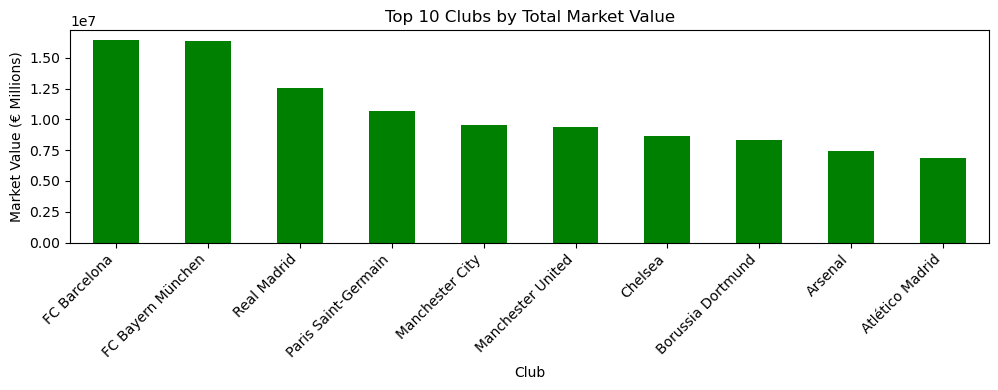

In [52]:
club = df.groupby('Club Name')['Value in Euro'].mean()
club = club.sort_values(ascending = False)
club = club.head(10)

fig, ax = plt.subplots(figsize = (10 , 4))

club.plot(
    kind = 'bar',
    ax = ax,
    color = 'green'
)

ax.set_title('Top 10 Clubs by Total Market Value')
ax.set_xlabel('Club')
ax.set_ylabel('Market Value (€ Millions)')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## BUBBLE CHART (Overall vs Potential)

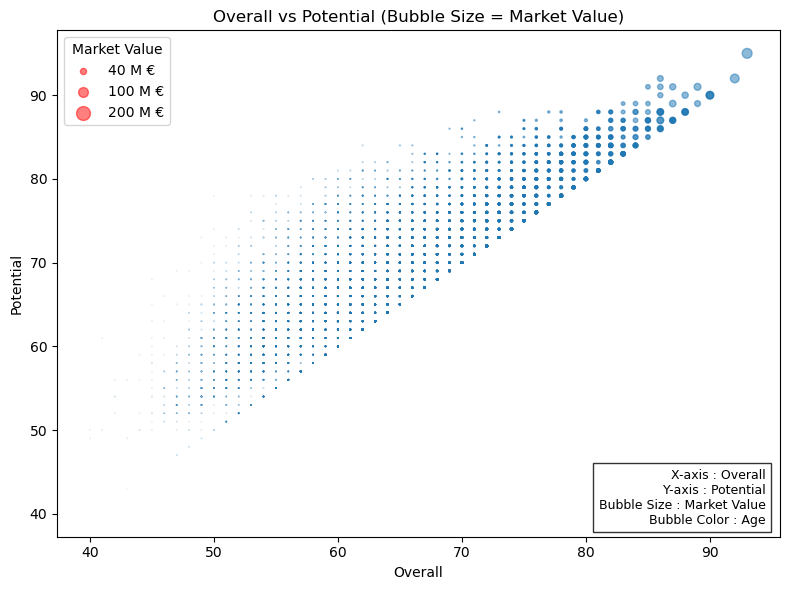

In [72]:
d = df.dropna(subset = ['Overall','Potential','Value in Euro'])

fig, ax = plt.subplots(figsize = (8,6))

scatter = ax.scatter(
    d['Overall'],
    d['Potential'],
    s = d['Value in Euro']/2e6,
    alpha = 0.5
)

for size in [20 , 50 , 100]:
    ax.scatter([], [], s = size,
               color = 'red',
               alpha = 0.5,
               label = f'{size*2} M €')

ax.text(
    0.98,
    0.02,
    'X-axis : Overall\n'
    'Y-axis : Potential\n'
    'Bubble Size : Market Value\n'
    'Bubble Color : Age',
    transform=ax.transAxes,
    fontsize=9,
    ha='right',
    va='bottom',
    bbox=dict(facecolor = 'white', alpha = 0.8)
)

ax.legend(title = 'Market Value')
plt.title('Overall vs Potential (Bubble Size = Market Value)')
plt.xlabel('Overall')
plt.ylabel('Potential')

plt.tight_layout()
plt.show()

## CORRELATION HEATMAP

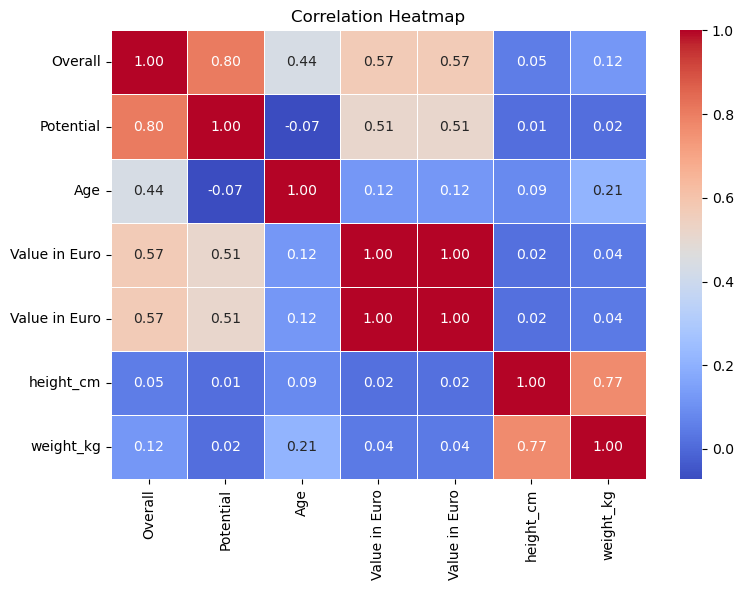

In [74]:
cols = [
    'Overall',
    'Potential',
    'Age',
    'Value in Euro',
    'Value in Euro',
    'height_cm',
    'weight_kg'
]

corr = df[cols].corr()

fig, ax = plt.subplots(figsize = (8 , 6))

sns.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f',
    linewidths = .5,
    ax = ax
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# Key Insights

- Most players are concentrated in the 20–30 age range.
- Higher overall ratings generally correspond to higher market values.
- Potential is strongly correlated with overall rating.
- Market values are highly right-skewed, with a few elite players dominating.
- Clubs differ substantially in average player quality and total squad value.
- Weekly wages generally increase with market value and player rating.
- Position influences both average rating and market value.